# Phase 1 — FAERS Quarterly ASCII ETL

### FAERS Intelligence Platform

This notebook ingests FDA Adverse Event Reporting System (FAERS) quarterly ASCII files,
deduplicates reports, normalizes drug names, and writes a single unified SQLite database
(`faers.db`) that downstream phases consume.

### Design highlights

1. **Strong positive-control coverage.** Three well-established positive-control drugs are
   tracked in addition to ciprofloxacin: `isotretinoin` (depression, cheilitis),
   `clozapine` (agranulocytosis, myocarditis), and `warfarin` (haemorrhage, INR increased).
   This removes the validation arm's prior dependence on a single drug.
2. **Robust legacy loader.** Withdrawn-era positives `rofecoxib`, `cerivastatin`, and
   `rosiglitazone` are parsed from the legacy AERS (LAERS) ASCII format, which uses `ISR`
   and lacks `prod_ai`. Failures are isolated (try/except) so the main Phase 1 pipeline
   never breaks. Enabled by default (`RUN_LEGACY=True`).
3. **Conservative L2 deduplication.** The fingerprint now includes reporter type
   (`occp_cod`) and is only applied to rows with **known age**, preventing over-merging
   of "common drug + common reaction + missing age" reports.
4. **Default 4 quarters** for stable background marginals and better coverage of sparse
   drugs. Adjust based on available RAM.

> **Handoff contract (invariant):** Phase 2 computes every 2x2 table from this single
> database. The background is the full corpus; targets are filtered subsets. Modern and
> legacy data are never mixed — legacy lives only in `*_legacy` tables.

## 1. Setup & Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, json, time, zipfile, hashlib, logging, sqlite3
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import requests
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/FAERS_Intelligence"
RAW_DIR     = os.path.join(PROJECT_DIR, "data", "raw")
FAERS_DIR   = os.path.join(PROJECT_DIR, "data", "faers_quarterly")
DB_DIR      = os.path.join(PROJECT_DIR, "data", "db")
for d in (RAW_DIR, FAERS_DIR, DB_DIR): os.makedirs(d, exist_ok=True)
DB_PATH = os.path.join(DB_DIR, "faers.db")

# Four most recent FAERS quarters (2023Q4 - 2024Q3)
QUARTERS = ["2024q3", "2024q2", "2024q1", "2023q4"]

# A registered target drug must have at least this many reports in modern FAERS
# to be considered worth analyzing
MIN_TARGET_REPORTS = 20

# Logging — file + stream so progress is visible in Colab and persisted on Drive
LOG_PATH = os.path.join(PROJECT_DIR, "phase1_run.log")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler()])
log = logging.getLogger("phase1")
log.info("Setup complete. Quarters=%s", QUARTERS)
print("Setup complete. DB ->", DB_PATH)

## 2. Target Drug Registry

- `role`: `pos` = positive control (validation), `neg` = negative control, `study` = drug of interest
- `era`: `modern` (analyzed in recent quarters) or `legacy` (withdrawn drugs loaded separately in section 11)

In [ ]:
TARGET_DRUGS = {
    # ---- positive controls (validation) — modern ----
    "ciprofloxacin": dict(group="validation", role="pos", era="modern",
                          syn=["ciprofloxacin","cipro"]),
    "isotretinoin":  dict(group="validation", role="pos", era="modern",
                          syn=["isotretinoin","accutane","claravis","amnesteem","absorica","myorisan","zenatane"]),
    "clozapine":     dict(group="validation", role="pos", era="modern",
                          syn=["clozapine","clozaril","fazaclo","versacloz"]),
    "warfarin":      dict(group="validation", role="pos", era="modern",
                          syn=["warfarin","coumadin","jantoven"]),
    # ---- positive controls — legacy (withdrawn) ----
    "rofecoxib":     dict(group="validation", role="pos", era="legacy",
                          syn=["rofecoxib","vioxx"]),
    "rosiglitazone": dict(group="validation", role="pos", era="legacy",
                          syn=["rosiglitazone","avandia","avandamet","avandaryl"]),
    "cerivastatin":  dict(group="validation", role="pos", era="legacy",
                          syn=["cerivastatin","baycol","lipobay"]),
    # ---- GSK / ViiV portfolio (study) ----
    "dolutegravir":  dict(group="gsk", role="study", era="modern",
                          syn=["dolutegravir","tivicay","triumeq","dovato","juluca"]),
    "cabotegravir":  dict(group="gsk", role="study", era="modern",
                          syn=["cabotegravir","vocabria","cabenuva","apretude"]),
    "mepolizumab":   dict(group="gsk", role="study", era="modern",
                          syn=["mepolizumab","nucala"]),
    # ---- trending (study) ----
    "semaglutide":   dict(group="trending", role="study", era="modern",
                          syn=["semaglutide","ozempic","wegovy","rybelsus"]),
    "tirzepatide":   dict(group="trending", role="study", era="modern",
                          syn=["tirzepatide","mounjaro","zepbound"]),
    "lecanemab":     dict(group="trending", role="study", era="modern",
                          syn=["lecanemab","leqembi"]),
    "pembrolizumab": dict(group="trending", role="study", era="modern",
                          syn=["pembrolizumab","keytruda"]),
    # ---- negative controls ----
    "metformin":     dict(group="negative_control", role="neg", era="modern",
                          syn=["metformin","glucophage","glumetza","fortamet"]),
    "lisinopril":    dict(group="negative_control", role="neg", era="modern",
                          syn=["lisinopril","prinivil","zestril"]),
    "omeprazole":    dict(group="negative_control", role="neg", era="modern",
                          syn=["omeprazole","prilosec","losec"]),
    "amoxicillin":   dict(group="negative_control", role="neg", era="modern",
                          syn=["amoxicillin","amoxil","trimox"]),
    "amlodipine":    dict(group="negative_control", role="neg", era="modern",
                          syn=["amlodipine","norvasc","katerzia"]),
}
MODERN_TARGETS={k:v for k,v in TARGET_DRUGS.items() if v["era"]=="modern"}
LEGACY_TARGETS={k:v for k,v in TARGET_DRUGS.items() if v["era"]=="legacy"}
print(f"Targets: {len(TARGET_DRUGS)} | modern={len(MODERN_TARGETS)} legacy={len(LEGACY_TARGETS)}")
print(f"Positive controls(modern): {[k for k,v in MODERN_TARGETS.items() if v['role']=='pos']}")
for k,v in TARGET_DRUGS.items():
    print(f"  [{v['role']:>5s}|{v['era'][:3]}|{v['group'][:3]}] {k}")

Targets: 19 | modern=16 legacy=3
Positive controls(modern): ['ciprofloxacin', 'isotretinoin', 'clozapine', 'warfarin']
  [  pos|mod|val] ciprofloxacin
  [  pos|mod|val] isotretinoin
  [  pos|mod|val] clozapine
  [  pos|mod|val] warfarin
  [  pos|leg|val] rofecoxib
  [  pos|leg|val] rosiglitazone
  [  pos|leg|val] cerivastatin
  [study|mod|gsk] dolutegravir
  [study|mod|gsk] cabotegravir
  [study|mod|gsk] mepolizumab
  [study|mod|tre] semaglutide
  [study|mod|tre] tirzepatide
  [study|mod|tre] lecanemab
  [study|mod|tre] pembrolizumab
  [  neg|mod|neg] metformin
  [  neg|mod|neg] lisinopril
  [  neg|mod|neg] omeprazole
  [  neg|mod|neg] amoxicillin
  [  neg|mod|neg] amlodipine


## 3. Download FAERS / AERS Quarterly ASCII (cached, with provenance)

Downloads quarterly ZIP archives from the FDA server and verifies integrity.

- **SHA-256 verification** detects corrupt downloads.
- **Caching** — already-extracted quarters are not re-downloaded.
- Modern quarters use the `faers_ascii_*` naming convention; pre-2012Q3 quarters use
  `aers_ascii_*` (LAERS). Both candidates are tried in order.
- Provenance (URL, SHA-256, download timestamp) is recorded for every quarter.

In [ ]:
# SHA-256 verification ensures downloaded ZIPs are not corrupted
def sha256_file(path, buf=1<<20):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for c in iter(lambda:f.read(buf),b""): h.update(c)
    return h.hexdigest()


def download_quarter(q):
    Q=q.upper()
    candidates=[f"https://fis.fda.gov/content/Exports/faers_ascii_{Q}.zip",
                f"https://fis.fda.gov/content/Exports/aers_ascii_{q}.zip",
                f"https://fis.fda.gov/content/Exports/aers_ascii_{Q}.zip"]
    zip_path=os.path.join(FAERS_DIR,f"q_{q}.zip")

    # Cache hit: skip re-download if the quarter has already been extracted
    extract_dir=os.path.join(FAERS_DIR,q)
    if os.path.isdir(extract_dir) and any(f.upper().endswith(".TXT")
            for _,_,fs in os.walk(extract_dir) for f in fs):
        log.info("[%s] already extracted", q)
        return extract_dir, dict(quarter=q, cached=True,
                                 sha256=sha256_file(zip_path) if os.path.exists(zip_path) else None)
    for url in candidates:
        try:
            r=requests.get(url,stream=True,timeout=120)
            if r.status_code!=200: continue
            total=int(r.headers.get("content-length",0))
            with open(zip_path,"wb") as f:
                done=0
                for chunk in r.iter_content(1<<16):
                    f.write(chunk); done+=len(chunk)
                    if total: print(f"\r  [{q}] {done/total*100:5.1f}%",end="")
            print()
            os.makedirs(extract_dir,exist_ok=True)
            with zipfile.ZipFile(zip_path) as z: z.extractall(extract_dir)
            sha=sha256_file(zip_path)
            log.info("[%s] extracted from %s (sha %s...)", q, url.split("/")[-1], sha[:10])
            return extract_dir, dict(quarter=q, url=url, sha256=sha,
                                     downloaded_at=datetime.now(timezone.utc).isoformat(), cached=False)
        except Exception as e:
            log.warning("[%s] %s failed: %s", q, url.split("/")[-1], e)
    log.error("[%s] all candidate URLs failed", q)
    return None, dict(quarter=q, error="download_failed")

quarter_dirs, provenance = {}, []
for q in QUARTERS:
    d,prov=download_quarter(q); provenance.append(prov)
    if d: quarter_dirs[q]=d
if not quarter_dirs:
    raise RuntimeError("All quarter downloads failed — check QUARTERS and network.")
print("Ready quarters:", list(quarter_dirs))

## 4. Robust ASCII Parser (FAERS + LAERS tolerant)

Reads FAERS's complex pipe-delimited text format and absorbs schema variations across eras.

- Field separator `$`, encoding `latin-1`
- Absorbs column-name variations: `primaryid`/`isr`, `caseid`/`case`, `sex`/`gndr_cod`,
  `caseversion`/`foll_seq`
- Age normalized to years using `age_cod`
- LAERS rows have no `prod_ai`, so the loader falls back to `drugname`

In [ ]:
import shutil, tempfile

def _find_table_file(qdir,kw):
    hits=[]
    for root,_,files in os.walk(qdir):
        for f in files:
            up=f.upper()
            if up.endswith(".TXT") and up.startswith(kw.upper()):
                hits.append(os.path.join(root,f))
    hits.sort(key=lambda p:("ASCII" not in p.upper(),len(p)))
    return hits[0] if hits else None

def _read_ascii(path, max_retries=3):
    if path is None: return pd.DataFrame()
    # Drive resilience: Google Drive intermittently disconnects when reading large files.
    # The workaround is to copy the file to local /tmp first, then read, with retry on failure.
    for attempt in range(max_retries):
        try:
            # Files on Drive: copy to /tmp before reading to avoid mid-read disconnects
            if path.startswith("/content/drive"):
                with tempfile.NamedTemporaryFile(suffix=".txt", delete=False) as tmp:
                    tmp_path = tmp.name
                shutil.copyfile(path, tmp_path)
                df = pd.read_csv(tmp_path, sep="$", engine="python",
                                 encoding="latin-1", dtype=str, on_bad_lines="skip")
                os.unlink(tmp_path)
            else:
                df = pd.read_csv(path, sep="$", engine="python",
                                 encoding="latin-1", dtype=str, on_bad_lines="skip")
            df.columns = [c.lower().strip() for c in df.columns]
            return df
        except OSError as e:
            if "Transport endpoint" in str(e) or e.errno == 107:
                log.warning(f"Drive disconnect on attempt {attempt+1}/{max_retries}, retrying...")
                time.sleep(3)
                # Attempt to remount Drive
                try:
                    drive.mount('/content/drive', force_remount=True)
                except: pass
                continue
            raise
    raise RuntimeError(f"Failed to read {path} after {max_retries} retries")

def _pick(df,*cands):
    for c in cands:
        if c in df.columns: return c
    return None

# Normalize age: FAERS stores age with a unit code (DY/WK/MO/YR/DEC) — convert all to years
AGE_DIV={"dec":0.1,"yr":1,"mon":12,"wk":52,"dy":365,"hr":8760,
         "801":1,"802":12,"803":52,"804":365,"800":0.1}
def normalize_age(age,cod):
    try: a=float(age)
    except (TypeError,ValueError): return np.nan
    if a<0 or a>120*8760: return np.nan
    c=str(cod).strip().lower() if cod is not None else "yr"
    div=AGE_DIV.get(c,1)
    yrs=a*10 if div==0.1 else a/div
    return round(yrs,1) if 0<=yrs<=120 else np.nan

SEX_MAP={"m":"Male","f":"Female","1":"Male","2":"Female","0":"Unknown","unk":"Unknown","ns":"Unknown"}
def norm_sex(x): return SEX_MAP.get(str(x).strip().lower(),"Unknown")
print("Parser helpers ready (Drive-disconnect resilient).")

Parser helpers ready (Drive-disconnect resilient).


## 5. Parse + Concatenate Quarterly Tables

Merges the per-quarter DataFrames into a single unified table per FAERS entity
(demo/drug/reac/outc/indi/ther/rpsr). The parser also absorbs era-specific differences
in role-code column names so the resulting tables have a consistent schema.

In [ ]:
def parse_demo(qdir,q):
    df=_read_ascii(_find_table_file(qdir,"DEMO"))
    if df.empty: return df
    pid=_pick(df,"primaryid","isr"); cid=_pick(df,"caseid","case","isr")
    ver=_pick(df,"caseversion","foll_seq","i_f_code")
    age=_pick(df,"age"); agec=_pick(df,"age_cod","age_unit")
    sex=_pick(df,"sex","gndr_cod")
    out=pd.DataFrame({
        "primaryid":df[pid].str.strip(),
        "caseid":(df[cid].str.strip() if cid else df[pid].str.strip()),
        "caseversion":(pd.to_numeric(df[ver],errors="coerce") if ver else 1),
        "age":[normalize_age(a,c) for a,c in zip(df[age] if age else [None]*len(df),
                                                 df[agec] if agec else [None]*len(df))],
        "sex":(df[sex].map(norm_sex) if sex else "Unknown"),
        "wt":(pd.to_numeric(df[_pick(df,"wt")],errors="coerce") if _pick(df,"wt") else np.nan),
        "event_dt":(df[_pick(df,"event_dt")] if _pick(df,"event_dt") else ""),
        "fda_dt":(df[_pick(df,"fda_dt","init_fda_dt")] if _pick(df,"fda_dt","init_fda_dt") else ""),
        "rept_cod":(df[_pick(df,"rept_cod")] if _pick(df,"rept_cod") else ""),
        "occp_cod":(df[_pick(df,"occp_cod")] if _pick(df,"occp_cod") else ""),
        "reporter_country":(df[_pick(df,"reporter_country","occr_country")]
                            if _pick(df,"reporter_country","occr_country") else ""),
    })
    out["source_quarter"]=q
    return out

def parse_drug(qdir,q):
    df=_read_ascii(_find_table_file(qdir,"DRUG"))
    if df.empty: return df
    pid=_pick(df,"primaryid","isr"); dn=_pick(df,"drugname"); ai=_pick(df,"prod_ai")
    out=pd.DataFrame({
        "primaryid":df[pid].str.strip(),
        "drug_seq":(df[_pick(df,"drug_seq","dsg_drug_seq")] if _pick(df,"drug_seq","dsg_drug_seq") else ""),
        "role_cod":(df[_pick(df,"role_cod")].str.strip().str.upper() if _pick(df,"role_cod") else "UNK"),
        "drugname":(df[dn].fillna("").str.strip() if dn else ""),
        "prod_ai":((df[ai] if ai else df[dn]).fillna("").str.lower().str.strip()),
        "route":(df[_pick(df,"route")] if _pick(df,"route") else ""),
        "dose_amt":(df[_pick(df,"dose_amt")] if _pick(df,"dose_amt") else ""),
    })
    out["source_quarter"]=q
    return out

def parse_reac(qdir,q):
    df=_read_ascii(_find_table_file(qdir,"REAC"))
    if df.empty: return df
    pid=_pick(df,"primaryid","isr"); pt=_pick(df,"pt","reac_pt","reactionmeddrapt")
    out=pd.DataFrame({"primaryid":df[pid].str.strip(),"pt":df[pt].fillna("").str.upper().str.strip()})
    out["source_quarter"]=q
    return out[out["pt"]!=""]

def parse_simple(qdir,q,kw,cols):
    df=_read_ascii(_find_table_file(qdir,kw))
    if df.empty: return df
    pid=_pick(df,"primaryid","isr")
    data={"primaryid":df[pid].str.strip()}
    for std,cands in cols.items():
        col=_pick(df,*cands); data[std]=df[col] if col else ""
    out=pd.DataFrame(data); out["source_quarter"]=q
    return out

D,DR,R,O,I,T,P=([] for _ in range(7))
for q,qdir in quarter_dirs.items():
    log.info("Parsing %s …", q)
    D.append(parse_demo(qdir,q)); DR.append(parse_drug(qdir,q)); R.append(parse_reac(qdir,q))
    O.append(parse_simple(qdir,q,"OUTC",{"outc_cod":["outc_cod","outc_code"]}))
    I.append(parse_simple(qdir,q,"INDI",{"indi_drug_seq":["indi_drug_seq","drug_seq"],"indi_pt":["indi_pt","indi_pt_cod"]}))
    T.append(parse_simple(qdir,q,"THER",{"dsg_drug_seq":["dsg_drug_seq","drug_seq"],"start_dt":["start_dt"],"end_dt":["end_dt"],"dur":["dur"],"dur_cod":["dur_cod"]}))
    P.append(parse_simple(qdir,q,"RPSR",{"rpsr_cod":["rpsr_cod"]}))

cat=lambda L:[d for d in L if d is not None and len(d)]
demo=pd.concat(cat(D),ignore_index=True); drug=pd.concat(cat(DR),ignore_index=True)
reac=pd.concat(cat(R),ignore_index=True)
outc=pd.concat(cat(O),ignore_index=True) if cat(O) else pd.DataFrame(columns=["primaryid","outc_cod"])
indi=pd.concat(cat(I),ignore_index=True) if cat(I) else pd.DataFrame(columns=["primaryid","indi_pt"])
ther=pd.concat(cat(T),ignore_index=True) if cat(T) else pd.DataFrame(columns=["primaryid"])
rpsr=pd.concat(cat(P),ignore_index=True) if cat(P) else pd.DataFrame(columns=["primaryid"])
print("Raw parsed rows (pre-dedup):")
for n,df in dict(demo=demo,drug=drug,reac=reac,outc=outc,indi=indi,ther=ther,rpsr=rpsr).items():
    print(f"  {n:<5s}: {len(df):>10,}")

Raw parsed rows (pre-dedup):
  demo :  1,624,195
  drug :  7,626,289
  reac :  5,822,211
  outc :  1,202,688
  indi :  4,666,835
  ther :  2,299,724
  rpsr :     47,223


## 6. Deduplication

Collapses redundant reports so frequency-based statistics are not inflated.

Two-level deduplication:

- **L1** — within `caseid`, keep only the latest `caseversion`.
- **L2 (fingerprint)** — even without names, treat two reports as identical when age,
  sex, country, event date, reporter type, drug set, and reaction set all match exactly.
  Applied **only to rows with known age** to avoid over-merging anonymized cases.

In [ ]:
n0=demo["primaryid"].nunique()
print(f"Unique primaryid (pre-dedup): {n0:,}")
demo["fda_dt_num"]=pd.to_numeric(demo["fda_dt"],errors="coerce")

# L1 deduplication — keep latest caseversion per caseid
demo=(demo.sort_values(["caseversion","fda_dt_num"],ascending=[False,False])
           .drop_duplicates("caseid",keep="first"))
n1=len(demo); print(f"L1 caseid->max version: kept {n1:,} (removed {n0-n1:,})")

ps=drug[drug["role_cod"]=="PS"].copy(); ps["prod_ai"]=ps["prod_ai"].fillna("")

# Build a deterministic fingerprint per primaryid
dfp=(ps.groupby("primaryid")["prod_ai"]
       .apply(lambda s:"|".join(sorted({x for x in s if x}))).rename("dfp"))
rfp=(reac.groupby("primaryid")["pt"]
       .apply(lambda s:"|".join(sorted({x for x in s if x})[:6])).rename("rfp"))
demo=demo.merge(dfp,on="primaryid",how="left").merge(rfp,on="primaryid",how="left")

def _k(x): return "" if pd.isna(x) else str(x)
demo["fp"]=(demo["age"].map(_k)+"|"+demo["sex"].map(_k)+"|"+demo["reporter_country"].map(_k)+"|"
            +demo["event_dt"].map(_k)+"|"+demo["occp_cod"].map(_k)+"|"
            +demo["dfp"].fillna("")+"|"+demo["rfp"].fillna(""))

# L2 conservative deduplication — applies only to rows with known age + drug + reaction
informative=(demo["age"].notna() & demo["dfp"].fillna("").str.len().gt(0)
             & demo["rfp"].fillna("").str.len().gt(0))
dups=demo[informative].sort_values(["caseversion","fda_dt_num"],ascending=[False,False])
keep_idx=dups.drop_duplicates("fp",keep="first").index
demo=pd.concat([demo[~informative],demo.loc[keep_idx]]).sort_index()
n2=len(demo)
print(f"L2 fingerprint(conservative): kept {n2:,} (removed {n1-n2:,}) "
      f"[applied to {int(informative.sum()):,} age-known rows; "
      f"{int((~informative).sum()):,} kept as-is]")

# Synchronize related tables to the deduplicated demo
valid=set(demo["primaryid"])
for nm in ["drug","reac","outc","indi","ther","rpsr"]:
    globals()[nm]=globals()[nm][globals()[nm]["primaryid"].isin(valid)].copy()
demo=demo.drop(columns=["dfp","rfp","fp","fda_dt_num"],errors="ignore")
print(f"\nDedup total: {n0:,} -> {n2:,} ({(n0-n2)/n0*100:.1f}% removed)")

## 7. Drug Name Normalization + Target Matching

Cleans up inconsistent drug-name strings and flags rows belonging to a tracked target drug.

- **Salt-token stripping** — removes `hydrochloride`, `sodium`, etc., to collapse variants
  to a single active ingredient.
- **Regex matching** against the target registry produces an `is_target` flag plus
  `target_drug`, `target_group`, and `target_role` columns.

In [ ]:
SALT_TOKENS={"hydrochloride","hcl","sodium","potassium","calcium","magnesium","maleate","mesylate",
 "mesilate","sulfate","sulphate","succinate","tartrate","besylate","besilate","fumarate","acetate",
 "citrate","phosphate","bromide","chloride","dihydrate","monohydrate","trihydrate","anhydrous",
 "hemifumarate","hydrobromide","nitrate","oxalate","pamoate","valerate","propionate"}
_nr=re.compile(r"[^a-z0-9 ]+")
def normalize_name(s):
    if not isinstance(s,str): return ""
    s=_nr.sub(" ",s.lower())
    return " ".join(t for t in s.split() if t and t not in SALT_TOKENS).strip()

drug["prod_ai_norm"]=drug["prod_ai"].map(normalize_name)
hay=(drug["drugname"].fillna("").str.lower()+" "+drug["prod_ai"].fillna("").str.lower())
drug["target_drug"]=""; drug["target_group"]=""; drug["target_role"]=""
for name,meta in TARGET_DRUGS.items():
    pat="|".join(re.escape(s) for s in meta["syn"])
    m=hay.str.contains(pat,regex=True,na=False)&(drug["target_drug"]=="")
    drug.loc[m,"target_drug"]=name; drug.loc[m,"target_group"]=meta["group"]; drug.loc[m,"target_role"]=meta["role"]
drug["is_target"]=(drug["target_drug"]!="").astype(int)
print(f"Target-tagged rows: {int(drug['is_target'].sum()):,} "
      f"across {drug.loc[drug.is_target==1,'primaryid'].nunique():,} reports")

def rxnorm_ingredient(name, cache={}):
    key=name.lower().strip()
    if key in cache: return cache[key]
    try:
        r=requests.get("https://rxnav.nlm.nih.gov/REST/rxcui.json",params={"name":key,"search":2},timeout=10)
        ids=r.json().get("idGroup",{}).get("rxnormId",[]) if r.ok else []
        ing=""
        if ids:
            pr=requests.get(f"https://rxnav.nlm.nih.gov/REST/rxcui/{ids[0]}/related.json",params={"tty":"IN"},timeout=10)
            for g in (pr.json().get("relatedGroup",{}).get("conceptGroup",[]) if pr.ok else []):
                for c in g.get("conceptProperties",[]): ing=c.get("name","").lower(); break
        cache[key]=ing; time.sleep(0.1); return ing
    except Exception:
        cache[key]=""; return ""
print("Normalizer + matcher ready.")

Target-tagged rows: 400,187 across 198,290 reports
Normalizer + matcher ready.


## 8. Outcome / Death Cross-Reference (ground-truth severity)

Attaches outcome codes (death, hospitalization, etc.) to each report.

The resulting `died` and `serious_any` flags are consumed by Phase 3 as ground-truth
inputs to the severity calibration step.

In [ ]:
OUTC_LABELS={"DE":"died","LT":"life_threatening","HO":"hospitalized","DS":"disability",
             "CA":"congenital_anomaly","RI":"required_intervention","OT":"other"}
outc["outc_cod"]=outc["outc_cod"].astype(str).str.strip().str.upper()
flags=(outc.assign(v=1).pivot_table(index="primaryid",columns="outc_cod",values="v",aggfunc="max",fill_value=0)
            .rename(columns=OUTC_LABELS))
for col in OUTC_LABELS.values():
    if col not in flags.columns: flags[col]=0
flags=flags[list(OUTC_LABELS.values())].reset_index()
demo=demo.merge(flags,on="primaryid",how="left")
for col in OUTC_LABELS.values(): demo[col]=demo[col].fillna(0).astype(int)
demo["serious_any"]=demo[["died","life_threatening","hospitalized","disability","congenital_anomaly"]].max(axis=1)
print(f"Death-flagged: {demo['died'].sum():,} ({demo['died'].mean()*100:.1f}%) | "
      f"serious: {demo['serious_any'].mean()*100:.1f}%")

Death-flagged: 106,913 (7.6%) | serious: 27.7%


## 9. Load into SQLite — full background + precomputed marginals

Writes every cleaned table to `faers.db`, creates indexes on `primaryid`, `pt`, and
`target_drug` for fast lookup in later phases, and stores pipeline metadata
(quarters, row counts, provenance).

In [ ]:
conn=sqlite3.connect(DB_PATH)
for name,df in dict(demo=demo,drug=drug,reac=reac,outc=outc,indi=indi,ther=ther,rpsr=rpsr).items():
    df.to_sql(name,conn,if_exists="replace",index=False); print(f"  stored {name:<5s}: {len(df):>9,}")
N_total=demo["primaryid"].nunique()
bg=(reac.merge(demo[["primaryid"]],on="primaryid").groupby("pt")["primaryid"].nunique()
        .rename("n_reports").reset_index().sort_values("n_reports",ascending=False))
bg.to_sql("bg_event_marginals",conn,if_exists="replace",index=False)
for idx in ["CREATE INDEX IF NOT EXISTS ix_demo_pid ON demo(primaryid)",
            "CREATE INDEX IF NOT EXISTS ix_drug_pid ON drug(primaryid)",
            "CREATE INDEX IF NOT EXISTS ix_drug_tgt ON drug(target_drug)",
            "CREATE INDEX IF NOT EXISTS ix_reac_pid ON reac(primaryid)",
            "CREATE INDEX IF NOT EXISTS ix_reac_pt ON reac(pt)",
            "CREATE INDEX IF NOT EXISTS ix_bg_pt ON bg_event_marginals(pt)"]:
    conn.execute(idx)
meta=[("built_at",datetime.now(timezone.utc).isoformat()),("schema_version","phase1_v6"),
      ("quarters",json.dumps(QUARTERS)),("n_reports_total",str(N_total)),
      ("n_unique_events",str(bg.shape[0])),("provenance",json.dumps(provenance))]
pd.DataFrame(meta,columns=["key","value"]).to_sql("meta",conn,if_exists="replace",index=False)
conn.commit(); conn.close()
print(f"\nDB ready: N_total={N_total:,} | events={bg.shape[0]:,} | {os.path.getsize(DB_PATH)/1e6:.0f} MB")

  stored demo : 1,409,287
  stored drug : 6,046,234
  stored reac : 4,730,495
  stored outc : 1,010,750
  stored indi : 3,801,456
  stored ther : 1,832,336
  stored rpsr :    46,182

DB ready: N_total=1,409,287 | events=16,282 | 1575 MB


## 10. Target Presence Report

In [ ]:
rows=[]
for name,meta in TARGET_DRUGS.items():
    n=drug.loc[drug["target_drug"]==name,"primaryid"].nunique()
    rows.append(dict(drug=name,role=meta["role"],group=meta["group"],era=meta["era"],reports=n))
present=pd.DataFrame(rows).sort_values(["era","role","reports"],ascending=[True,True,False])
print(present.to_string(index=False))
sparse=present[present["reports"]<MIN_TARGET_REPORTS]
if len(sparse):
    print("\nSparse in modern data:")
    for _,r in sparse.iterrows():
        print(f"   - {r['drug']} ({r['era']}, {r['reports']}) -> "
              + ("loaded as legacy (section 11)" if r['era']=='legacy' else "add quarters or replace drug"))
pos_modern=present[(present.role=="pos")&(present.era=="modern")&(present.reports>=MIN_TARGET_REPORTS)]
print(f"\nUsable modern positive controls: {list(pos_modern['drug'])}")

## 11. Legacy AERS (withdrawn positive controls) — era-isolated

Loads withdrawn-era positives (`rofecoxib` 2004 withdrawal, `rosiglitazone` 2007 peak
concern) from their original AERS quarters and writes them to `*_legacy` tables.
**Never mixed with the modern background.** (`cerivastatin` withdrew in 2001, before AERS
ASCII coverage begins in 2004, so it is excluded.)

If a legacy quarter download fails the section silently skips it without affecting the
rest of Phase 1.

In [ ]:
RUN_LEGACY = True
LEGACY_QUARTERS = ["2004q3", "2007q3"]   # rofecoxib (2004), rosiglitazone (2007)

if RUN_LEGACY:
    try:
        ld,ldr,lr,lo=[],[],[],[]
        for q in LEGACY_QUARTERS:
            d,prov=download_quarter(q); provenance.append(prov)
            if not d: continue
            ld.append(parse_demo(d,q)); ldr.append(parse_drug(d,q)); lr.append(parse_reac(d,q))
            lo.append(parse_simple(d,q,"OUTC",{"outc_cod":["outc_cod","outc_code"]}))
        if ld:
            Ld=pd.concat(ld,ignore_index=True); Ldr=pd.concat(ldr,ignore_index=True)
            Lr=pd.concat(lr,ignore_index=True)
            Lo=pd.concat(lo,ignore_index=True) if lo and any(len(x) for x in lo) else pd.DataFrame(columns=["primaryid","outc_cod"])
            Ld["fda_dt_num"]=pd.to_numeric(Ld["fda_dt"],errors="coerce")
            Ld=(Ld.sort_values(["caseversion","fda_dt_num"],ascending=[False,False])
                   .drop_duplicates("caseid",keep="first"))
            valid=set(Ld["primaryid"]); Ldr=Ldr[Ldr.primaryid.isin(valid)]; Lr=Lr[Lr.primaryid.isin(valid)]
            Ldr["prod_ai_norm"]=Ldr["prod_ai"].map(normalize_name)
            hay=(Ldr["drugname"].fillna("").str.lower()+" "+Ldr["prod_ai"].fillna("").str.lower())
            Ldr["target_drug"]=""; Ldr["target_group"]=""; Ldr["target_role"]=""
            for name,meta in LEGACY_TARGETS.items():
                pat="|".join(re.escape(s) for s in meta["syn"])
                m=hay.str.contains(pat,regex=True,na=False)&(Ldr["target_drug"]=="")
                Ldr.loc[m,"target_drug"]=name; Ldr.loc[m,"target_group"]=meta["group"]; Ldr.loc[m,"target_role"]=meta["role"]
            Ldr["is_target"]=(Ldr["target_drug"]!="").astype(int)
            N_leg=Ld["primaryid"].nunique()
            bg_leg=(Lr.merge(Ld[["primaryid"]],on="primaryid").groupby("pt")["primaryid"].nunique()
                      .rename("n_reports").reset_index())
            conn=sqlite3.connect(DB_PATH)
            Ld.assign(era="legacy").to_sql("demo_legacy",conn,if_exists="replace",index=False)
            Ldr.assign(era="legacy").to_sql("drug_legacy",conn,if_exists="replace",index=False)
            Lr.assign(era="legacy").to_sql("reac_legacy",conn,if_exists="replace",index=False)
            Lo.assign(era="legacy").to_sql("outc_legacy",conn,if_exists="replace",index=False)
            bg_leg.to_sql("bg_event_marginals_legacy",conn,if_exists="replace",index=False)
            conn.execute("INSERT INTO meta VALUES (?,?)",("legacy_N",str(N_leg)))
            conn.execute("INSERT INTO meta VALUES (?,?)",("legacy_quarters",json.dumps(LEGACY_QUARTERS)))
            conn.commit(); conn.close()
            for nm in LEGACY_TARGETS:
                c=Ldr.loc[Ldr.target_drug==nm,"primaryid"].nunique()
                print(f"  legacy {nm}: {c:,} reports")
            print(f"Legacy loaded: N={N_leg:,}. Phase 2 computes 2x2 tables *within* legacy only.")
        else:
            print("All legacy quarters failed to download — skipping (main pipeline unaffected).")
    except Exception as e:
        print(f"Exception during legacy load (ignored): {e}")
else:
    print("RUN_LEGACY=False — skipping legacy era.")

## 12. Exploratory Data Analysis

DATASET SUMMARY
Reports (deduped) : 1,409,287
Unique events(PT) : 16,282
Unique drugs(norm): 7,221
Death/serious     : 7.6% / 27.7%
Sex F/M/Unk       : 49/33/18%
Age median        : 60 (missing 44%)


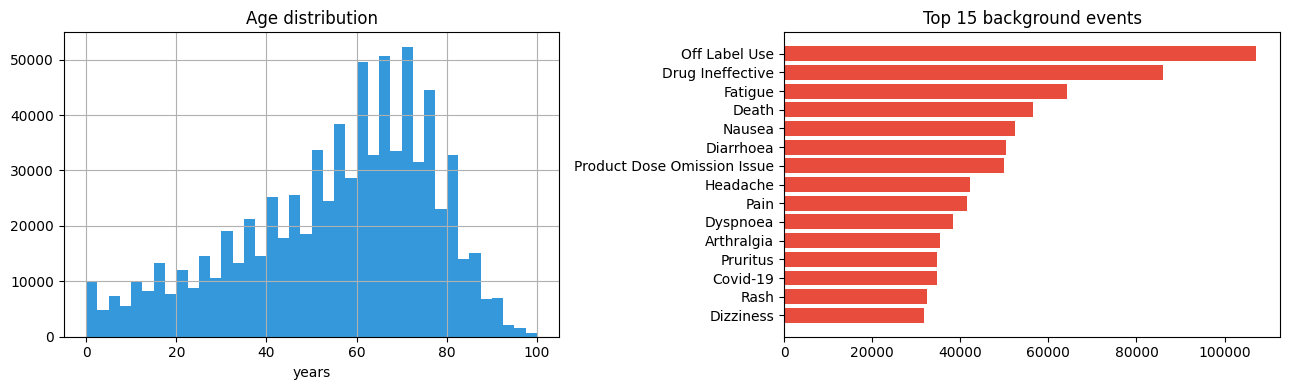

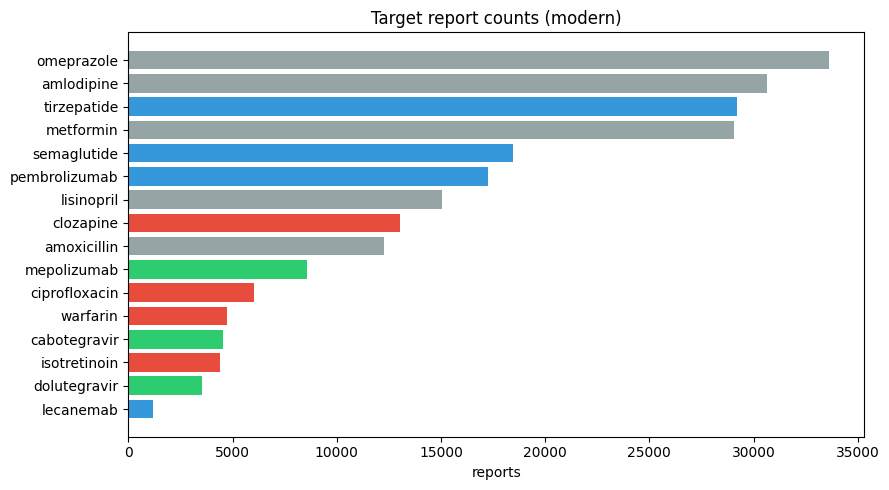

In [ ]:
import matplotlib.pyplot as plt
FIG_DIR=os.path.join(PROJECT_DIR,"figures"); os.makedirs(FIG_DIR,exist_ok=True)
print("="*60,"\nDATASET SUMMARY\n","="*60,sep="")
print(f"Reports (deduped) : {N_total:,}")
print(f"Unique events(PT) : {bg.shape[0]:,}")
print(f"Unique drugs(norm): {drug['prod_ai_norm'].nunique():,}")
print(f"Death/serious     : {demo['died'].mean()*100:.1f}% / {demo['serious_any'].mean()*100:.1f}%")
print(f"Sex F/M/Unk       : {(demo['sex']=='Female').mean()*100:.0f}/"
      f"{(demo['sex']=='Male').mean()*100:.0f}/{(demo['sex']=='Unknown').mean()*100:.0f}%")
print(f"Age median        : {demo['age'].median():.0f} (missing {demo['age'].isna().mean()*100:.0f}%)")

fig,ax=plt.subplots(1,2,figsize=(13,4))
demo["age"].dropna().clip(0,100).hist(bins=40,ax=ax[0],color="#3498db")
ax[0].set_title("Age distribution"); ax[0].set_xlabel("years")
top=bg.head(15).iloc[::-1]
ax[1].barh(top["pt"].str.title(),top["n_reports"],color="#e74c3c")
ax[1].set_title("Top 15 background events")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"00_eda_overview.png"),dpi=110); plt.show()

pm=present[present["era"]=="modern"].sort_values("reports")
colors={"validation":"#e74c3c","gsk":"#2ecc71","trending":"#3498db","negative_control":"#95a5a6"}
plt.figure(figsize=(9,5))
plt.barh(pm["drug"],pm["reports"],color=[colors[g] for g in pm["group"]])
plt.title("Target report counts (modern)"); plt.xlabel("reports")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"00_target_counts.png"),dpi=110); plt.show()

## 13. Data-Quality Assertions

In [ ]:
problems=[]
if demo["primaryid"].duplicated().any(): problems.append("duplicate primaryid")
if (demo["age"].dropna()<0).any() or (demo["age"].dropna()>120).any(): problems.append("age out of range")
if set(drug["primaryid"])-set(demo["primaryid"]): problems.append("orphan primaryid in drug table")
if set(reac["primaryid"])-set(demo["primaryid"]): problems.append("orphan primaryid in reac table")
if bg["n_reports"].max()>N_total: problems.append("marginal > N")
if drug["is_target"].sum()==0: problems.append("zero target matches")
pos_ok=present[(present.role=='pos')&(present.era=='modern')&(present.reports>=MIN_TARGET_REPORTS)]
if len(pos_ok)<2: problems.append("fewer than 2 modern positive controls — check quarters/drugs")
print("Issues found:" if problems else "All quality checks passed.")
[print("  -",p) for p in problems]
print(f"\nmax marginal {bg['n_reports'].max():,} <= N {N_total:,} "
      f"({bg['n_reports'].max()/N_total*100:.1f}%)")

## 14. Phase 1 Complete — Handoff Contract to Phase 2

**Outputs (single `faers.db`):**
`demo` (with `died`/`serious_any`), `drug` (with `prod_ai_norm`/`target_drug`/`target_group`/
`target_role`/`is_target`), `reac`/`outc`/`indi`/`ther`/`rpsr`, `bg_event_marginals`,
`meta` (N_total, quarters, provenance), and optionally `*_legacy` tables.

**Phase 2 contract:**
1. `a` = unique primaryid in the same DB where `target_drug == X` and `pt == Y`
2. `n_event` = `bg_event_marginals[Y]`
3. `N` = `meta.n_reports_total`
4. Apply +0.5 Haldane-Anscombe correction for zero cells
5. Compute true empirical-Bayes shrinkage EBGM
6. Legacy 2x2 tables come from `*_legacy` tables only — never mixed with modern.

In [ ]:
print("="*60)
print("Phase 1 (v6) complete — finalized single-source ETL")
print("="*60)
print(f"DB:{DB_PATH}  N={N_total:,}  quarters={QUARTERS}")
print("Next: Phase 2 v6.")

Phase 1 (v6) complete — finalized single-source ETL
DB:/content/drive/MyDrive/FAERS_Intelligence/data/db/faers.db  N=1,409,287  quarters=['2024q3', '2024q2', '2024q1', '2023q4']
Next: Phase 2 v6.
